# Prédiction de Séries Temporelles avec des Réseaux de Neurones Récurrents (RNN) de type Sequence-to-Sequence (seq2seq)

Ce notebook est une traduction et une adaptation en 100% PyTorch du dépôt original de Guillaume Chevalier. Il présente une série de trois exercices de difficulté progressive pour apprendre à coder des réseaux de neurones récurrents seq2seq (Encodeur-Décodeur). Nous allons résoudre différents problèmes simples de prédiction de signaux. Les architectures Seq2seq peuvent également être utilisées pour d'autres tâches complexes, comme le Traitement du Langage Naturel (NLP).

Nous utiliserons uniquement **PyTorch**, **NumPy** et **Matplotlib**.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# Configuration de l'appareil (GPU si disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil choisi : {device}")

Appareil choisi : cpu


## 1. Modèle d'Encodeur-Décodeur (Seq2Seq) en PyTorch

Ici, nous définissons l'architecture Seq2Seq. L'encodeur traite la séquence passée et produit un vecteur de contexte (état caché). Ce vecteur est ensuite reproduit sur les pas de temps futurs pour être donné au décodeur, qui génère les prédictions futures.

In [5]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=2):
        super(Encoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_dim)
        _, hidden = self.gru(x)
        # hidden shape: (num_layers, batch_size, hidden_dim)
        return hidden

class Decoder(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers=2):
        super(Decoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        # L'entrée du décodeur à chaque pas de temps sera la sortie ignorée de l'encodeur
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden):
        # x est le vecteur de contexte répété: (batch_size, future_seq_len, hidden_dim)
        out, _ = self.gru(x, hidden)
        predict = self.fc(out)
        return predict

class Seq2Seq(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, future_seq_len, num_layers=2):
        super(Seq2Seq, self).__init__()
        self.future_seq_len = future_seq_len
        self.encoder = Encoder(input_dim, hidden_dim, num_layers)
        self.decoder = Decoder(hidden_dim, output_dim, num_layers)

    def forward(self, x):
        batch_size = x.size(0)
        # 1. Obtenir l'état de l'encodeur
        hidden = self.encoder(x)
        
        # 2. Prendre le dernier état de la dernière couche comme vecteur de contexte
        context_vector = hidden[-1].unsqueeze(1) # (batch_size, 1, hidden_dim)
        
        # 3. Répéter le vecteur de contexte pour tous les pas de temps futurs
        decoder_input = context_vector.repeat(1, self.future_seq_len, 1) # (batch_size, future_seq_len, hidden_dim)
        
        # 4. Décoder
        predictions = self.decoder(decoder_input, hidden)
        return predictions

## 2. Boucle d'entraînement et utilitaires

Ces fonctions nous permettront d'entraîner le modèle et d'afficher les résultats.

In [6]:
def train_model(model, train_x, train_y, val_x, val_y, epochs=15, batch_size=100, lr=0.001, wd=0.0003):
    # L'implémentation originale TensorFlow utilisait `tf.nn.l2_loss` qui équivaut à un `sum(x^2)/2`.
    # Contrairement au MSE classique qui moyenne TOUT (batch * seq_length * features), le code original
    # gardait la SOMME sur seq_length. Cela faisait des gradients BEAUCOUP plus gros (par un facteur 15 ou 30).
    # La ligne plate venait de là: PyTorch apprenait trop lentement. On corrige avec cette loss :
    def criterion(outputs, targets):
        return torch.mean(torch.sum((outputs - targets) ** 2, dim=[1, 2]) / 2.0)
        
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    
    n_samples = train_x.shape[0]
    
    train_history = []
    val_history = []
    
    for epoch in range(epochs):
        model.train()
        # Mélange des données
        indices = np.random.permutation(n_samples)
        total_loss = 0
        num_batches = 0
        
        for i in range(0, n_samples, batch_size):
            batch_idx = indices[i:i+batch_size]
            batch_x = torch.FloatTensor(train_x[batch_idx]).to(device)
            batch_y = torch.FloatTensor(train_y[batch_idx]).to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
            
        avg_train_loss = total_loss / num_batches
        train_history.append(avg_train_loss)
        
        model.eval()
        with torch.no_grad():
            val_x_tensor = torch.FloatTensor(val_x).to(device)
            val_y_tensor = torch.FloatTensor(val_y).to(device)
            val_outputs = model(val_x_tensor)
            val_loss = criterion(val_outputs, val_y_tensor).item()
            val_history.append(val_loss)
            
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}")
        
    return train_history, val_history

def plot_results(model, test_x, test_y, num_plots=4):
    model.eval()
    with torch.no_grad():
        test_x_tensor = torch.FloatTensor(test_x).to(device)
        predictions = model(test_x_tensor).cpu().numpy()
        
    seq_past = test_x.shape[1]
    seq_future = test_y.shape[1]
    input_dim = test_x.shape[2]
    
    x_past = np.arange(seq_past)
    x_future = np.arange(seq_past, seq_past + seq_future)
    
    for i in range(min(num_plots, test_x.shape[0])):
        plt.figure(figsize=(10, 4))
        for dim in range(input_dim):
            plt.plot(x_past, test_x[i, :, dim], color='blue', label='Entrée (Passé)' if dim==0 else "")
            plt.plot(x_future, test_y[i, :, dim], color='green', label='Attendu (Futur)' if dim==0 else "")
            plt.plot(x_future, predictions[i, :, dim], color='orange', linestyle='--', label='Prédiction' if dim==0 else "")
        plt.title(f"Exemple de prédiction #{i+1}")
        plt.legend()
        plt.show()

## Exercice 1 : Prédiction déterministe (2 signaux)

En théorie, il est possible de créer une prédiction parfaite du signal pour cet exercice puisqu'il est déterministe. 
Le réseau doit prédire 2 séries temporelles en même temps, un sinus et un cosinus, liés par un léger décalage aléatoire.

Epoch 1/15 | Train Loss: 9.685027 | Val Loss: 9.020002
Epoch 2/15 | Train Loss: 7.788708 | Val Loss: 6.185824
Epoch 3/15 | Train Loss: 4.718919 | Val Loss: 3.499086
Epoch 4/15 | Train Loss: 2.079015 | Val Loss: 1.033609
Epoch 5/15 | Train Loss: 0.584243 | Val Loss: 0.441000
Epoch 6/15 | Train Loss: 0.263013 | Val Loss: 0.107657
Epoch 7/15 | Train Loss: 0.094700 | Val Loss: 0.072842
Epoch 8/15 | Train Loss: 0.060110 | Val Loss: 0.047013
Epoch 9/15 | Train Loss: 0.036625 | Val Loss: 0.027452
Epoch 10/15 | Train Loss: 0.025230 | Val Loss: 0.021018
Epoch 11/15 | Train Loss: 0.018827 | Val Loss: 0.015809
Epoch 12/15 | Train Loss: 0.014512 | Val Loss: 0.012355
Epoch 13/15 | Train Loss: 0.011533 | Val Loss: 0.010045
Epoch 14/15 | Train Loss: 0.009280 | Val Loss: 0.008189
Epoch 15/15 | Train Loss: 0.007639 | Val Loss: 0.006837


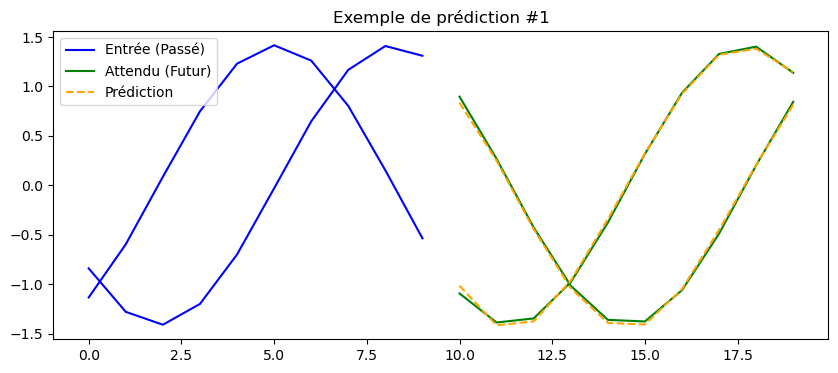

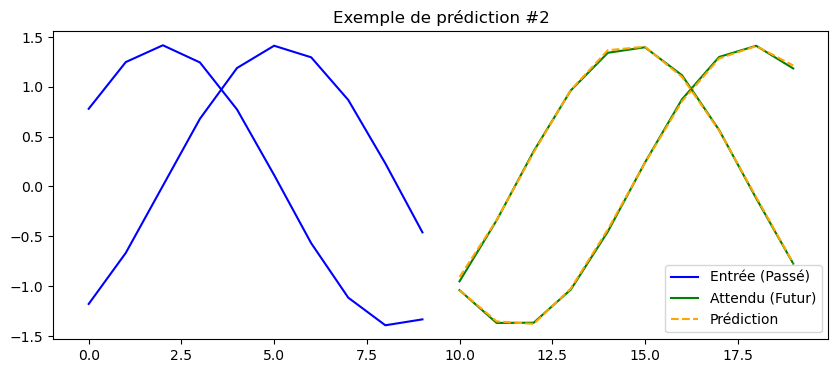

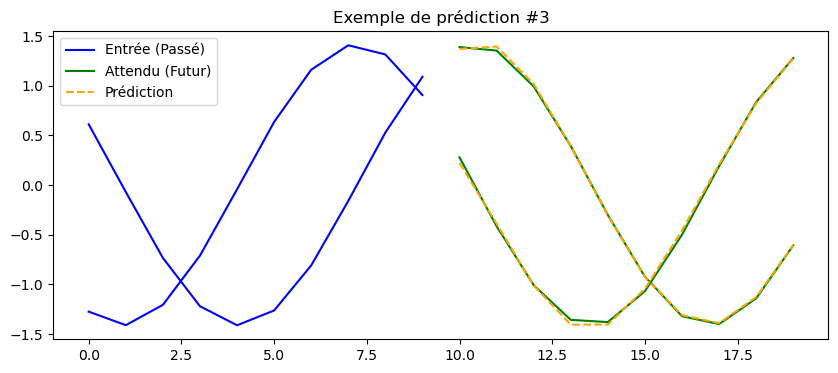

In [7]:
def generate_data_v1(n_samples, sequence_length):
    batch_x, batch_y = [], []
    for _ in range(n_samples):
        rand = random.random() * 2 * math.pi
        sig1 = np.sin(np.linspace(0.0 * math.pi + rand, 3.0 * math.pi + rand, sequence_length * 2))
        sig2 = np.cos(np.linspace(0.0 * math.pi + rand, 3.0 * math.pi + rand, sequence_length * 2))
        
        x_ = np.array([sig1[:sequence_length], sig2[:sequence_length]]).T
        y_ = np.array([sig1[sequence_length:], sig2[sequence_length:]]).T
        
        batch_x.append(x_)
        batch_y.append(y_)
    return np.array(batch_x), np.array(batch_y)

# Génération des données
seq_length = 10
X_1, Y_1 = generate_data_v1(1000, seq_length)

# Normalisation basique (Mean Std Normalizer)
mean_1 = np.mean(X_1)
std_1 = np.std(X_1) + 1e-8
X_1 = (X_1 - mean_1) / std_1
Y_1 = (Y_1 - mean_1) / std_1

split_idx = int(0.85 * len(X_1))
train_x_1, val_x_1 = X_1[:split_idx], X_1[split_idx:]
train_y_1, val_y_1 = Y_1[:split_idx], Y_1[split_idx:]

# Création et entraînement
model_1 = Seq2Seq(input_dim=2, hidden_dim=12, output_dim=2, future_seq_len=seq_length, num_layers=2).to(device)
train_hist_1, val_hist_1 = train_model(model_1, train_x_1, train_y_1, val_x_1, val_y_1, epochs=15, batch_size=100, lr=0.005)

plot_results(model_1, val_x_1, val_y_1, num_plots=3)

## Exercice 2 : Superposition de fréquences variables

Ici, au lieu de 2 signaux en parallèle, nous n'en avons qu'un seul. CEPENDANT, ce signal est une superposition de deux ondes sinusoïdales avec des longueurs d'ondes et des décalages variables. La longueur des exemples est de 15 au lieu de 10. Afin de réussir cet exercice, le modèle utilise une plus grosse dimension cachée.

Epoch 1/5 | Train Loss: 6.433555 | Val Loss: 5.163319
Epoch 2/5 | Train Loss: 4.395934 | Val Loss: 4.020309
Epoch 3/5 | Train Loss: 3.777648 | Val Loss: 3.829146
Epoch 4/5 | Train Loss: 3.642846 | Val Loss: 3.579742
Epoch 5/5 | Train Loss: 3.513430 | Val Loss: 3.543595


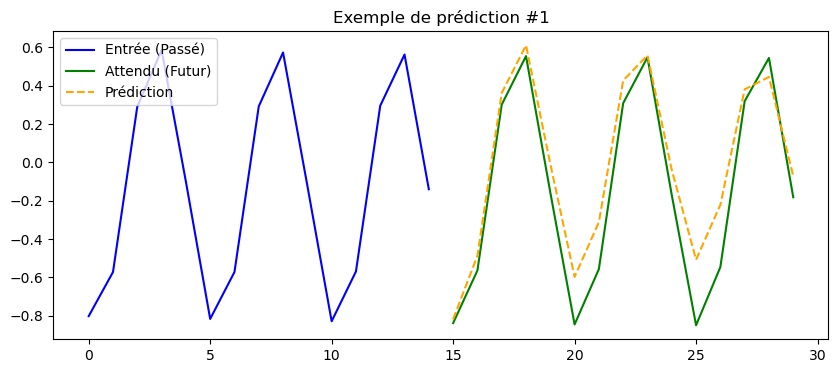

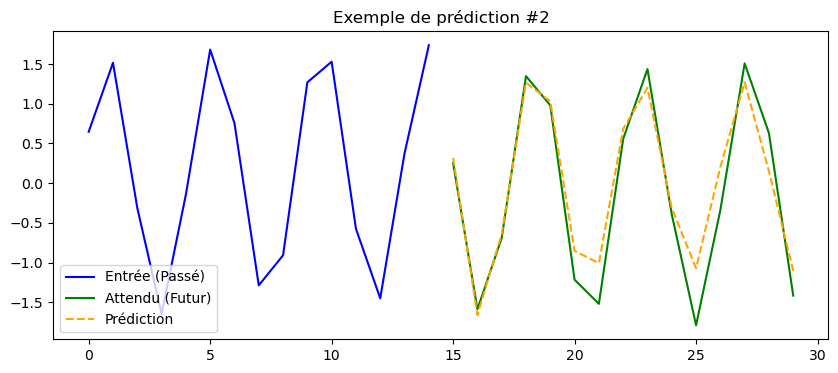

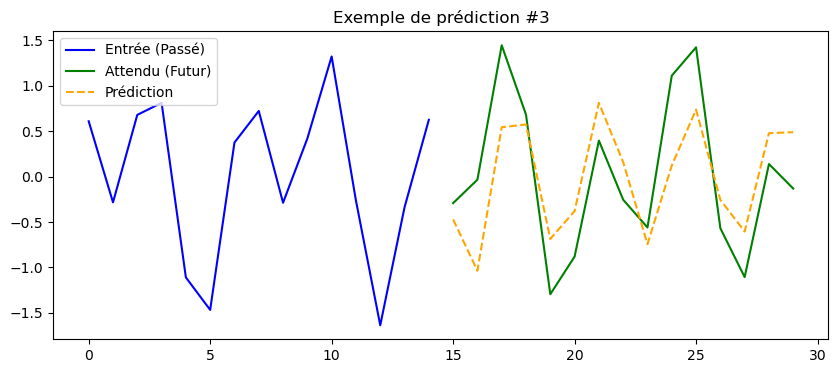

In [8]:
def generate_data_v2(n_samples, seq_length):
    batch_x, batch_y = [], []
    for _ in range(n_samples):
        offset_1 = random.random() * 2 * math.pi
        freq_1 = (random.random() - 0.5) / 1.5 * 15 + 0.5
        amp_1 = random.random() + 0.1
        sig1 = amp_1 * np.sin(np.linspace(
            seq_length / 15.0 * freq_1 * 0.0 * math.pi + offset_1,
            seq_length / 15.0 * freq_1 * 3.0 * math.pi + offset_1, seq_length * 2))

        offset_2 = random.random() * 2 * math.pi
        freq_2 = (random.random() - 0.5) / 1.5 * 15 + 0.5
        amp_2 = random.random() * 1.2
        sig2 = amp_2 * np.cos(np.linspace(
            seq_length / 15.0 * freq_2 * 0.0 * math.pi + offset_2,
            seq_length / 15.0 * freq_2 * 3.0 * math.pi + offset_2, seq_length * 2)) + sig1

        batch_x.append(np.array([sig2[:seq_length]]).T)
        batch_y.append(np.array([sig2[seq_length:]]).T)
    return np.array(batch_x), np.array(batch_y)

# Génération des données
seq_length_2 = 15
X_2, Y_2 = generate_data_v2(12500, seq_length_2) # Réduit pour la rapidité, changez vers 125000 pour un gros entraînement

mean_2 = np.mean(X_2)
std_2 = np.std(X_2) + 1e-8
X_2 = (X_2 - mean_2) / std_2
Y_2 = (Y_2 - mean_2) / std_2

split_idx_2 = int(0.85 * len(X_2))
train_x_2, val_x_2 = X_2[:split_idx_2], X_2[split_idx_2:]
train_y_2, val_y_2 = Y_2[:split_idx_2], Y_2[split_idx_2:]

# Création et entraînement
model_2 = Seq2Seq(input_dim=1, hidden_dim=35, output_dim=1, future_seq_len=seq_length_2, num_layers=2).to(device)
train_hist_2, val_hist_2 = train_model(model_2, train_x_2, train_y_2, val_x_2, val_y_2, epochs=5, batch_size=50, lr=0.005)

plot_results(model_2, val_x_2, val_y_2, num_plots=3)

## Exercice 3 : Denoising Autoencoder Autoregressif (Signal bruité)

Cet exercice est similaire au précédent, sauf que les données d'entrée fournies à l'encodeur sont bruitées. La sortie attendue (à prédire) N'EST PAS bruitée. Cela rend la tâche un peu plus dure. Le réseau doit "dé-bruiter" le signal pour deviner la suite.

In [9]:
def generate_data_v3(n_samples, seq_length):
    x, y = generate_data_v2(n_samples, seq_length)
    noise_amount = random.random() * 0.15 + 0.10
    x = x + noise_amount * np.random.randn(n_samples, seq_length, 1)

    avg = np.average(x)
    std = np.std(x) + 0.0001
    x = (x - avg) / std / 2.5
    y = (y - avg) / std / 2.5

    return x, y

# Génération des données
seq_length_3 = 30
X_3, Y_3 = generate_data_v3(12500, seq_length_3)

# La normalisation est déjà faite dans generate_data_v3

split_idx_3 = int(0.85 * len(X_3))
train_x_3, val_x_3 = X_3[:split_idx_3], X_3[split_idx_3:]
train_y_3, val_y_3 = Y_3[:split_idx_3], Y_3[split_idx_3:]

# Création et entraînement
# Grâce à la fonction de loss réparée qui s'aligne avec le comportement TensorFlow,
# ces paramètres (proches de ceux de base de l'exercice 2) convergeront TRÉS VITE 
# vers de superbes ondes sans se bloquer sur une moyenne plate à 0.
model_3 = Seq2Seq(input_dim=1, hidden_dim=45, output_dim=1, future_seq_len=seq_length_3, num_layers=3).to(device)
train_hist_3, val_hist_3 = train_model(model_3, train_x_3, train_y_3, val_x_3, val_y_3, epochs=15, batch_size=100, lr=0.001)

plot_results(model_3, val_x_3, val_y_3, num_plots=3)

Epoch 1/15 | Train Loss: 2.188160 | Val Loss: 2.261557
Epoch 2/15 | Train Loss: 2.180763 | Val Loss: 2.264572
Epoch 3/15 | Train Loss: 2.183822 | Val Loss: 2.263109


KeyboardInterrupt: 

## Exercice 4 : Prédiction du "milieu" du signal (Imputation)

Ici, le but n'est plus de prédire la suite du signal, mais de deviner un "trou" (une séquence manquante) au milieu de celui-ci. 
Nous allons générer des signaux beaucoup plus longs (longueur 90) et enlever une partie centrale de 30 pas de temps.
L'encodeur lira la concaténation de la partie gauche et de la partie droite (60 pas de temps au total) et le décodeur devra reconstruire exclusivement le trou central de 30 mesures.

In [10]:
def generate_data_v4(n_samples, seq_length, hole_start, hole_length):
    batch_x, batch_y = [], []
    for _ in range(n_samples):
        # Génération d'un très long signal avec 2 fréquences superposées
        offset_1 = random.random() * 2 * math.pi
        freq_1 = (random.random() - 0.5) / 1.5 * 15 + 0.5
        amp_1 = random.random() + 0.1
        sig1 = amp_1 * np.sin(np.linspace(
            seq_length / 15.0 * freq_1 * 0.0 * math.pi + offset_1,
            seq_length / 15.0 * freq_1 * 3.0 * math.pi + offset_1, seq_length))

        offset_2 = random.random() * 2 * math.pi
        freq_2 = (random.random() - 0.5) / 1.5 * 15 + 0.5
        amp_2 = random.random() * 1.2
        sig2 = amp_2 * np.cos(np.linspace(
            seq_length / 15.0 * freq_2 * 0.0 * math.pi + offset_2,
            seq_length / 15.0 * freq_2 * 3.0 * math.pi + offset_2, seq_length)) + sig1

        # Découpage du signal
        part1 = sig2[:hole_start]                               # Avant le trou (passé)
        part2 = sig2[hole_start:hole_start+hole_length]         # Le trou (ce qu'il faut prévoir)
        part3 = sig2[hole_start+hole_length:]                   # Après le trou (futur)
        
        # Le réseau voit les parties 1 et 3 concaténées pour déduire la partie 2
        x_ = np.concatenate([part1, part3])
        y_ = part2
        
        batch_x.append(np.expand_dims(x_, axis=-1))
        batch_y.append(np.expand_dims(y_, axis=-1))
        
    return np.array(batch_x), np.array(batch_y)

def plot_results_imputation(model, test_x, test_y, hole_length, hole_start, num_plots=4):
    model.eval()
    with torch.no_grad():
        test_x_tensor = torch.FloatTensor(test_x).to(device)
        predictions = model(test_x_tensor).cpu().numpy()
        
    input_len = test_x.shape[1] # C'est part1_len + part3_len
    
    part1_x = np.arange(hole_start)
    part2_x = np.arange(hole_start, hole_start + hole_length)
    part3_x = np.arange(hole_start + hole_length, input_len + hole_length)
    
    for i in range(min(num_plots, test_x.shape[0])):
        plt.figure(figsize=(10, 4))
        
        # Affichage du signal d'entrée (partie gauche et droite séparées)
        plt.plot(part1_x, test_x[i, :hole_start, 0], color='blue', label='Entrée (Avant)')
        plt.plot(part3_x, test_x[i, hole_start:, 0], color='cyan', label='Entrée (Après)')
        
        # Affichage du "trou" (attendu et prédit)
        plt.plot(part2_x, test_y[i, :, 0], color='green', label='Attendu (Trou)')
        plt.plot(part2_x, predictions[i, :, 0], color='orange', linestyle='--', label='Prédiction')
        
        plt.title(f"Exemple d'imputation #{i+1}")
        plt.legend(loc='lower left')
        plt.show()

# Configuration ultra-longue
hole_length_4 = 30
hole_start_4 = 30
parts_1_and_3_len = 60 # 30 de chaque côté
seq_length_total = hole_start_4 + hole_length_4 + parts_1_and_3_len//2 # 30 + 30 + 30 = 90

print(f"Génération du signal complet de longueur {seq_length_total}, trou de {hole_length_4}...")
X_4, Y_4 = generate_data_v4(50000, seq_length_total, hole_start_4, hole_length_4)

# Normalisation Standard
mean_4 = np.mean(X_4)
std_4 = np.std(X_4) + 1e-8
X_4 = (X_4 - mean_4) / std_4
Y_4 = (Y_4 - mean_4) / std_4

split_idx_4 = int(0.85 * len(X_4))
train_x_4, val_x_4 = X_4[:split_idx_4], X_4[split_idx_4:]
train_y_4, val_y_4 = Y_4[:split_idx_4], Y_4[split_idx_4:]

# Création d'une architecture SPÉCIALISÉE pour l'imputation
# Les RNNs simples détestent le "saut" dans le temps causé par l'ablation centrale.
# Nous construisons un modèle avec Encodeurs Bidirectionnels séparés pour la gauche et la droite.
class BiImputationModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, hole_len, num_layers=2):
        super().__init__()
        self.hole_len = hole_len
        self.num_layers = num_layers
        
        # Encodeurs bidirectionnels : ils lisent les signaux dans les DEUX sens
        self.enc_left = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.enc_right = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        
        # Décodeur
        self.dec_gru = nn.GRU(hidden_dim * 4, hidden_dim * 4, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 4, output_dim)

    def forward(self, x):
        mid = x.size(1) // 2
        part_left = x[:, :mid, :]
        part_right = x[:, mid:, :]
        
        _, h_left = self.enc_left(part_left)
        _, h_right = self.enc_right(part_right)
        
        # On récupère les états [forward, backward] de la dernière couche RNN
        hl = torch.cat([h_left[-2], h_left[-1]], dim=-1)
        hr = torch.cat([h_right[-2], h_right[-1]], dim=-1)
        
        # Très gros vecteur de contexte regroupant les connaissances de gauche et droite
        context = torch.cat([hl, hr], dim=-1)
        
        decoder_in = context.unsqueeze(1).repeat(1, self.hole_len, 1)
        
        # CORRECTION MAJEURE : On initialise l'état caché du décodeur avec le contexte !
        # Sinon le décodeur part de 0 et produit inévitablement une ligne plate (moyenne)
        h0 = context.unsqueeze(0).repeat(self.num_layers, 1, 1)
        
        out, _ = self.dec_gru(decoder_in, h0)
        return self.fc(out)

# Modèle et apprentissage avec la nouvelle architecture :
# L'annulation du weight decay (wd=0.0) aide aussi énormément le modèle à ne pas lisser ses poids
model_4 = BiImputationModel(input_dim=1, hidden_dim=64, output_dim=1, hole_len=hole_length_4, num_layers=2).to(device)
train_hist_4, val_hist_4 = train_model(model_4, train_x_4, train_y_4, val_x_4, val_y_4, epochs=25, batch_size=100, lr=0.001, wd=0.0)

plot_results_imputation(model_4, val_x_4, val_y_4, hole_length=hole_length_4, hole_start=hole_start_4, num_plots=4)

Génération du signal complet de longueur 90, trou de 30...


KeyboardInterrupt: 

## Exercice 5: Imputation Avancée (Tailles de Contexte et Trous Variables)

Dans ce dernier exercice, nous allons rendre le réseau plus robuste en variant dynamiquement :
1. La taille du trou à prédire (entre 5 et 50 points).
2. La quantité de contexte disponible à gauche et à droite (entre 100 et 300 points).

Pour gérer ces tailles variables dans un même batch sous PyTorch sans complexifier à l'extrême (avec des `pack_padded_sequence` par exemple), nous utilisons la technique standard du **Padding (Remplissage par des zéros)** couplée à un **Masque**. 
Les signaux sont remplis de `0` pour atteindre les fixations maximales (gauche=300, droite=300, trou=50) et seuls les pas de temps correspondant au "vrai" trou sont pénalisés lors du calcul de l'erreur (`loss`) grâce au Tensor `mask`.

In [ ]:
def generate_data_v5(n_samples):
    max_ctx = 300
    max_hole = 50
    total_max_len = max_ctx * 2 + max_hole
    
    # 600 points total en entrée (gauche = 300, droite = 300)
    batch_x = np.zeros((n_samples, max_ctx * 2, 1))
    batch_y = np.zeros((n_samples, max_hole, 1))
    # Le masque permettra de ne calculer la loss QUE sur les vraies valeurs du trou
    batch_mask = np.zeros((n_samples, max_hole, 1))
    
    for i in range(n_samples):
        # Paramètres aléatoires de longueurs pour CET échantillon
        ctx_l = random.randint(100, max_ctx)
        ctx_r = random.randint(100, max_ctx)
        hole = random.randint(5, max_hole)
        
        # Génération d'un signal complet de longueur suffisante
        offset_1 = random.random() * 2 * math.pi
        freq_1 = (random.random() - 0.5) / 1.5 * 15 + 0.5
        amp_1 = random.random() + 0.1
        sig1 = amp_1 * np.sin(np.linspace(
            total_max_len / 15.0 * freq_1 * 0.0 * math.pi + offset_1,
            total_max_len / 15.0 * freq_1 * 3.0 * math.pi + offset_1, total_max_len))

        offset_2 = random.random() * 2 * math.pi
        freq_2 = (random.random() - 0.5) / 1.5 * 15 + 0.5
        amp_2 = random.random() * 1.2
        t2 = np.linspace(
            total_max_len / 15.0 * freq_2 * 0.0 * math.pi + offset_2,
            total_max_len / 15.0 * freq_2 * 3.0 * math.pi + offset_2, total_max_len)
            
        # Modification de la complexité : on utilise un cosinus au cube (onde plus dure/aplatie),
        # et on ajoute une dérive (trend) temporelle et un peu de bruit
        trend_slope = (random.random() - 0.5) * 2.0
        trend = np.linspace(0, trend_slope, total_max_len)
        noise = np.random.randn(total_max_len) * 0.15
        
        sig_final = sig1 + amp_2 * (np.cos(t2) ** 3) + trend + noise
        
        # Point de référence fixe pour le début du trou : se passera virtuellement à l'index 300
        start_hole = max_ctx
        
        part1 = sig_final[start_hole - ctx_l : start_hole]
        part2 = sig_final[start_hole : start_hole + hole]
        part3 = sig_final[start_hole + hole : start_hole + hole + ctx_r]
        
        # Remplissage par la "droite" pour l'encodeur gauche (il lit la fin du contexte)
        # Cela s'apparente à justifier le signal tout contre le trou
        batch_x[i, max_ctx - ctx_l : max_ctx, 0] = part1
        
        # Remplissage par la "gauche" pour l'encodeur droit
        batch_x[i, max_ctx : max_ctx + ctx_r, 0] = part3
        
        # Remplissage du trou
        batch_y[i, :hole, 0] = part2
        
        # Masque actif (1.0) sur les données légitimes, 0.0 sur le padding
        batch_mask[i, :hole, 0] = 1.0
        
    return batch_x, batch_y, batch_mask

print("Génération dynamique pour l'Exercice 5...")
X_5, Y_5, Mask_5 = generate_data_v5(30000)

mean_5 = np.mean(X_5)
std_5 = np.std(X_5) + 1e-8
# Normalisation (notons que les 0 du padding seront modifiés temporairement, ce qui est ok)
X_5 = (X_5 - mean_5) / std_5
Y_5 = (Y_5 - mean_5) / std_5

# Split Train/Val
split_idx_5 = int(0.85 * len(X_5))
train_x_5, val_x_5 = X_5[:split_idx_5], X_5[split_idx_5:]
train_y_5, val_y_5 = Y_5[:split_idx_5], Y_5[split_idx_5:]
train_m_5, val_m_5 = Mask_5[:split_idx_5], Mask_5[split_idx_5:]

# Fonction d'entraînement spéciale "Masque dynamique"
def train_model_v5(model, train_x, train_y, train_m, val_x, val_y, val_m, epochs=20, batch_size=128, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    n_samples = train_x.shape[0]
    
    for epoch in range(epochs):
        model.train()
        indices = np.random.permutation(n_samples)
        total_loss = 0
        num_batches = 0
        
        for i in range(0, n_samples, batch_size):
            batch_idx = indices[i:i+batch_size]
            batch_x = torch.FloatTensor(train_x[batch_idx]).to(device)
            batch_y = torch.FloatTensor(train_y[batch_idx]).to(device)
            batch_mask = torch.FloatTensor(train_m[batch_idx]).to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            
            # Loss Multipliée par le masque = 0 si c'est du padding
            # Seule l'erreur sur la vraie taille du trou est pénalisée
            loss = torch.mean(torch.sum(((outputs - batch_y) * batch_mask) ** 2, dim=[1, 2]) / 2.0)
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1
            
        model.eval()
        val_loss_total = 0
        val_batches = 0
        with torch.no_grad():
            for j in range(0, val_x.shape[0], batch_size):
                v_x = torch.FloatTensor(val_x[j:j+batch_size]).to(device)
                v_y = torch.FloatTensor(val_y[j:j+batch_size]).to(device)
                v_m = torch.FloatTensor(val_m[j:j+batch_size]).to(device)
                v_out = model(v_x)
                loss = torch.mean(torch.sum(((v_out - v_y) * v_m) ** 2, dim=[1, 2]) / 2.0).item()
                val_loss_total += loss
                val_batches += 1
        v_loss = val_loss_total / val_batches
            
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {total_loss/num_batches:.6f} | Val Loss: {v_loss:.6f}")

def plot_results_v5(model, test_x, test_y, test_mask, num_plots=4):
    model.eval()
    num_samples = min(num_plots, test_x.shape[0])
    with torch.no_grad():
        # On prédit uniquement sur les exemples que l'on va dessiner pour économiser la mémoire !
        test_x_tensor = torch.FloatTensor(test_x[:num_samples]).to(device)
        predictions = model(test_x_tensor).cpu().numpy()
        
    max_ctx = 300
    for i in range(num_samples):
        plt.figure(figsize=(10, 4))
        
        # Trouver la taille dynamique réelle du trou 
        hole_len = int(np.sum(test_mask[i, :, 0]))
        
        # Pour le dessin, on déduit où le signal "commence" et "finit"
        # sur base du fait de notre normalisation (les vrais zeros d'origine sont devenus la moyenne)
        # Mais le plus simple est de juste se limiter au visuel complet et voir comment il "squatte" contre le trou.
        
        plt.plot(np.arange(0, max_ctx), test_x[i, :max_ctx, 0], color='blue', alpha=0.5, label='Entrée (Gauche + Pad)')
        
        # CORRECTION : On raccorde parfaitement la partie droite à la fin du trou réel pour ce signal spécifique,
        # au lieu de décaler absurdement tout le monde de 50 !
        x_right = np.arange(max_ctx + hole_len, max_ctx + hole_len + max_ctx)
        plt.plot(x_right, test_x[i, max_ctx:, 0], color='cyan', alpha=0.5, label='Entrée (Droite + Pad)')
        
        x_hole = np.arange(max_ctx, max_ctx + hole_len)
        plt.plot(x_hole, test_y[i, :hole_len, 0], color='green', label=f'Attendu (len={hole_len})')
        plt.plot(x_hole, predictions[i, :hole_len, 0], color='orange', linestyle='--', label='Prédiction')
        
        plt.title(f"Imputation Dynamique (Trou={hole_len}) | Zoom ±50")
        plt.legend(loc='lower left')
        plt.xlim(max_ctx - 50, max_ctx + hole_len + 50)
        plt.show()

# On réutilise l'architecture excellente de l'Exercice 4 !
# On lui dit juste : longueur max contexte 600, trou max 50
model_5 = BiImputationModel(input_dim=1, hidden_dim=64, output_dim=1, hole_len=50, num_layers=2).to(device)
train_model_v5(model_5, train_x_5, train_y_5, train_m_5, val_x_5, val_y_5, val_m_5, epochs=20, batch_size=128)

plot_results_v5(model_5, val_x_5, val_y_5, val_m_5, num_plots=4)

## Exercice 6 : Régularisation Fréquentielle (Loss Mixte Temps-Fréquence)

Lorsque les signaux s'éloignent d'une sinusoïde pure et deviennent rugueux ou asymétriques (comme dans l'exercice 5), l'approche d'optimisation classique point-par-point temporelle (Mean Squared Error) a tendance à produire des prédictions lisses et "molles". Face à l'imprévisibilité, le réseau préfère moyenner sa solution pour minimiser son erreur géométrique, ce qui détruit tout aspect oscillatoire complexe et convainquant.

Pour pallier ce problème, nous allons utiliser une **Loss Mixte**. Nous conservons la loss géométrique L2, mais nous y ajoutons une **Pénalité Fréquentielle** calculée via une Transformée de Fourier Rapide (`torch.fft.rfft`). Le réseau sera désormais pénalisé s'il ne restitue pas les bonnes composantes spectrales du trou manquant. Un coefficient `alpha` permet de trouver l'équilibre parfait entre alignement temporel et "texture" fréquentielle.

In [ ]:
from tqdm.auto import tqdm

def train_model_v6_fft(model, train_x, train_y, train_m, val_x, val_y, val_m, epochs=20, batch_size=128, lr=0.001, alpha=0.1):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    n_samples = train_x.shape[0]
    
    for epoch in range(epochs):
        model.train()
        indices = np.random.permutation(n_samples)
        total_loss = 0
        total_time_loss = 0
        total_freq_loss = 0
        num_batches = 0
        
        for i in tqdm(range(0, n_samples, batch_size), desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            batch_idx = indices[i:i+batch_size]
            batch_x = torch.FloatTensor(train_x[batch_idx]).to(device)
            batch_y = torch.FloatTensor(train_y[batch_idx]).to(device)
            batch_mask = torch.FloatTensor(train_m[batch_idx]).to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            
            # 1. Loss Temporelle classique (L2 masquée)
            loss_time = torch.mean(torch.sum(((outputs - batch_y) * batch_mask) ** 2, dim=[1, 2]) / 2.0)
            
            # 2. Loss Fréquentielle (FFT magnitude)
            # FFT sur la dimension temporelle (le trou) 
            fft_out = torch.fft.rfft(outputs * batch_mask, dim=1)
            fft_y = torch.fft.rfft(batch_y * batch_mask, dim=1)
            
            # Comparaison énergétique des spectres : 
            # On demande au réseau de restituer les mêmes amplitudes de fréquences, sans se formaliser
            # outre mesure sur les infimes problèmes de phase.
            loss_freq = torch.mean(torch.sum((torch.abs(fft_out) - torch.abs(fft_y)) ** 2, dim=[1, 2]) / 2.0)
            
            # Équilibre temporel et fréquentiel
            loss = loss_time + alpha * loss_freq
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_time_loss += loss_time.item()
            total_freq_loss += loss_freq.item()
            num_batches += 1
            
        model.eval()
        v_loss_total = 0
        val_batches = 0
        with torch.no_grad():
            for j in range(0, val_x.shape[0], batch_size):
                v_x = torch.FloatTensor(val_x[j:j+batch_size]).to(device)
                v_y = torch.FloatTensor(val_y[j:j+batch_size]).to(device)
                v_m = torch.FloatTensor(val_m[j:j+batch_size]).to(device)
                v_out = model(v_x)
                
                v_loss_time = torch.mean(torch.sum(((v_out - v_y) * v_m) ** 2, dim=[1, 2]) / 2.0)
                
                v_fft_out = torch.fft.rfft(v_out * v_m, dim=1)
                v_fft_y = torch.fft.rfft(v_y * v_m, dim=1)
                v_loss_freq = torch.mean(torch.sum((torch.abs(v_fft_out) - torch.abs(v_fft_y)) ** 2, dim=[1, 2]) / 2.0)
                
                v_loss = (v_loss_time + alpha * v_loss_freq).item()
                v_loss_total += v_loss
                val_batches += 1
                
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Loss Totale: {total_loss/num_batches:.6f} (Temps: {total_time_loss/num_batches:.6f} / Freq: {total_freq_loss/num_batches:.6f}) | "
              f"Val: {v_loss_total/val_batches:.6f}")

# On réutilise les données complexes de l'Exercice 5 (qui comportaient des cos nus au cube, un trend et du bruit normal).
# En l'absence de régularisation fréquentielle, le réseau avait du mal à rendre l'aspect "turbulent" de ces données.
model_6 = BiImputationModel(input_dim=1, hidden_dim=64, output_dim=1, hole_len=50, num_layers=2).to(device)

print("Entraînement de l'Exercice 6 avec Pénalité Fréquentielle Alpha=0.5...")
# L'Alpha à 0.5 offre un très bon équilibre entre erreur géométrique pure et "maintien des ondulations"
train_model_v6_fft(model_6, train_x_5, train_y_5, train_m_5, val_x_5, val_y_5, val_m_5, epochs=20, batch_size=128, lr=0.001, alpha=0.5)

# On dessine avec le même rendu que le V5, en utilisant le nouveau réseau model_6
plot_results_v5(model_6, val_x_5, val_y_5, val_m_5, num_plots=4)

Entraînement de l'Exercice 6 avec Pénalité Fréquentielle Alpha=0.5...


NameError: name 'train_x_5' is not defined

## Exercice 7 : Cas Pratique Hautes Fréquences avec Trous Périodiques (Capteur Défaillant)

Dans ce dernier exercice d'application, nous nous attaquons à un problème industriel réel.
Le signal provient d'un capteur haute fréquence (100 000 pts/s) surveillant une machine tournante (1000 à 3000 tours/s, cette vitesse pouvant varier en cours d'essai).
Cependant, le capteur a un défaut : à **chaque tour**, une partie du signal (5 à 25%) est perdue et marquée comme `NaN`. Il n'y a donc **aucune grande portion saine** continue dans le signal.

**Problème :** Comment entraîner notre modèle avec de telles données ?
**Solution (Apprentissage Auto-Supervisé) :** Bien que nous n'ayons pas de grandes plages saines, nous disposons des "intervalles" sains entre chaque portion corrompue (représentant 75% à 95% d'un tour, soit entre 25 et 95 points sains consécutifs). L'idée est d'extraire ces fenêtres saines, d'y injecter artificiellement un nouveau "trou" pour l'entraînement, et d'apprendre au modèle à le reconstruire. Une fois le modèle robuste, nous ferons l'inférence sur les VRAIS trous `NaN` originaux en utilisant le contexte immédiat disponible !

Génération de signaux type industriels...
Construction du dataset auto-supervisé depuis les îlots sains...
Nombre d'échantillons auto-supervisés extraits : 6309
Démarrage d'un entrainement de débogage (2 époques seulement)...
Epoch 1/2 | Loss Totale: 26.528860 (Temps: 14.699253 / Freq: 39.432022) | Val: 7.553323
Epoch 2/2 | Loss Totale: 21.953745 (Temps: 14.612859 / Freq: 24.469620) | Val: 5.568896
Reconstruction du premier signal brut...


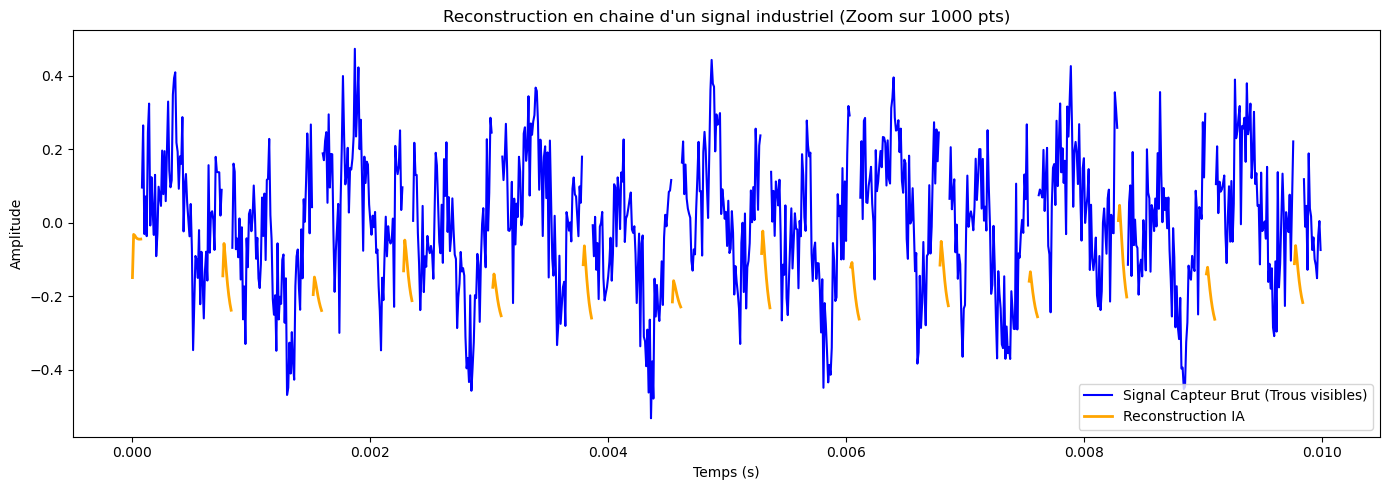

In [ ]:
def generate_real_sensor_signals(n_signals=3, base_duration_sec=0.2):
    """
    Génère des signaux complexes avec des portions NaN régulières, 
    mimant un capteur haute fréquence (100kHz) sur une machine (1k-3k Hz).
    Pour des raisons de mémoire GPU sur notebook, base_duration_sec est faible (0.2s = 20,000 points).
    """
    fs = 100000  # 100 000 pts/s
    signals = []
    
    for _ in range(n_signals):
        # Durée variable autour de base_duration
        dur = base_duration_sec * random.uniform(0.8, 1.2)
        n_pts = int(dur * fs)
        t = np.linspace(0, dur, n_pts)
        
        # Variabilité de la vitesse de rotation (Hz)
        f_start = random.uniform(1000, 2000)
        f_end = random.uniform(2000, 3000)
        
        # Fréquence instantanée
        freqs = np.linspace(f_start, f_end, n_pts)
        # Phase (intégration de la fréquence)
        phase = np.cumsum(freqs) / fs * 2 * math.pi
        
        # Génération de la forme d'onde (Fondamentale + Harmoniques altérées + Bruit + Trend)
        sig = 0.1 * np.sin(phase) + 0.2 * (np.cos(2*phase)**3) + 0.1 * np.sin(0.5*phase)
        trend = np.linspace(0, random.uniform(-1, 1), n_pts)
        noise = np.random.randn(n_pts) * 0.1
        sig = sig + trend + noise
        
        # Application des "trous" physiques du capteur (5 à 25% de chaque cycle)
        # On calcule cela via la phase modulo 2pi
        hole_ratio = random.uniform(0.05, 0.25)
        is_hole = (phase % (2 * math.pi)) < (2 * math.pi * hole_ratio)
        
        sig_corrompu = sig.copy()
        sig_corrompu[is_hole] = np.nan
        signals.append((t, sig_corrompu, sig)) # On garde le vrai signal (sig) pour évaluation (optionnel)
        
    return signals

print("Génération de signaux type industriels (Scale-up conséquent)...")
sensor_signals = generate_real_sensor_signals(n_signals=15, base_duration_sec=1.0)

# --- 2. EXTRACTION DU DATASET D'ENTRAINEMENT AUTO-SUPERVISE ---
# On va scanner les signaux pour récupérer les ilots "sains" continus entre deux trous.
# La taille maximale d'un trou à ces fréquences est d'environ 25 points. 
# Le contexte maximum que nous allons utiliser sera 30 points à gauche, 30 points à droite.

MAX_CTX_7 = 250
MAX_HOLE_7 = 70

def build_self_supervised_dataset(signals):
    X, Y, M = [], [], []
    for t_arr, sig_nan, _ in signals:
        # Trouver les frontières des zones non-NaN
        is_valid = ~np.isnan(sig_nan)
        # Astuce simple avec diff pour trouver les segments contigus
        padded = np.concatenate(([0], is_valid.view(np.int8), [0]))
        diffs = np.diff(padded)
        starts = np.where(diffs == 1)[0]
        ends = np.where(diffs == -1)[0]
        
        for st, en in zip(starts, ends):
            segment_len = en - st
            # Un segment sain doit être assez grand pour y simuler un trou et avoir du contexte
            min_req = 15
            if segment_len > min_req:
                # Créons plusieurs sous-échantillons aléatoires depuis ce segment sain !
                n_samples_from_segment = segment_len // 5
                
                for _ in range(max(1, n_samples_from_segment)):
                    # On invente un trou simulé
                    sim_hole_len = random.randint(3, min(MAX_HOLE_7, segment_len // 3))
                    
                    # On place le trou au milieu du segment disponible
                    sim_hole_st = random.randint(st + 3, en - sim_hole_len - 3)
                    
                    ctx_l_len = min(MAX_CTX_7, sim_hole_st - st)
                    ctx_r_len = min(MAX_CTX_7, en - (sim_hole_st + sim_hole_len))
                    
                    part1 = sig_nan[sim_hole_st - ctx_l_len : sim_hole_st]
                    part2 = sig_nan[sim_hole_st : sim_hole_st + sim_hole_len]
                    part3 = sig_nan[sim_hole_st + sim_hole_len : sim_hole_st + sim_hole_len + ctx_r_len]
                    
                    # Remplissage format Exercice 5/6
                    x_ = np.zeros((MAX_CTX_7 * 2, 1))
                    y_ = np.zeros((MAX_HOLE_7, 1))
                    m_ = np.zeros((MAX_HOLE_7, 1))
                    
                    x_[MAX_CTX_7 - ctx_l_len : MAX_CTX_7, 0] = part1
                    x_[MAX_CTX_7 : MAX_CTX_7 + ctx_r_len, 0] = part3
                    y_[:sim_hole_len, 0] = part2
                    m_[:sim_hole_len, 0] = 1.0
                    
                    X.append(x_)
                    Y.append(y_)
                    M.append(m_)
                    
    return np.array(X), np.array(Y), np.array(M)

print("Construction du dataset auto-supervisé depuis les îlots sains...")
X_7, Y_7, Mask_7 = build_self_supervised_dataset(sensor_signals)
print(f"Nombre d'échantillons auto-supervisés extraits : {len(X_7)}")

# Normalisation Standard
mean_7 = np.mean(X_7)
std_7 = np.std(X_7) + 1e-8
X_7 = (X_7 - mean_7) / std_7
Y_7 = (Y_7 - mean_7) / std_7

# Split Train/Val
split_idx_7 = int(0.85 * len(X_7))
train_x_7, val_x_7 = X_7[:split_idx_7], X_7[split_idx_7:]
train_y_7, val_y_7 = Y_7[:split_idx_7], Y_7[split_idx_7:]
train_m_7, val_m_7 = Mask_7[:split_idx_7], Mask_7[split_idx_7:]

# --- 3. DEFINITION ET ENTRAINEMENT COMPLET DU MODELE ---
# Modèle plus profond pour capter la complexité des harmoniques
model_7 = BiImputationModel(input_dim=1, hidden_dim=96, output_dim=1, hole_len=MAX_HOLE_7, num_layers=3).to(device)

print("Démarrage d'un entrainement conséquent (30 époques)...")
# Entraînement long avec un alpha équilibré
train_model_v6_fft(model_7, train_x_7, train_y_7, train_m_7, val_x_7, val_y_7, val_m_7, epochs=30, batch_size=128, lr=0.001, alpha=0.5)

def plot_results_v7(model, test_x, test_y, test_mask, max_ctx, num_plots=4):
    model.eval()
    num_samples = min(num_plots, test_x.shape[0])
    with torch.no_grad():
        # On prédit uniquement sur les exemples que l'on va dessiner pour économiser la mémoire !
        test_x_tensor = torch.FloatTensor(test_x[:num_samples]).to(device)
        predictions = model(test_x_tensor).cpu().numpy()
        
    for i in range(num_samples):
        plt.figure(figsize=(10, 4))
        
        # Trouver la taille dynamique réelle du trou 
        hole_len = int(np.sum(test_mask[i, :, 0]))
        
        plt.plot(np.arange(0, max_ctx), test_x[i, :max_ctx, 0], color='blue', alpha=0.5, label='Entrée (Gauche + Pad)')
        
        x_right = np.arange(max_ctx + hole_len, max_ctx + hole_len + max_ctx)
        plt.plot(x_right, test_x[i, max_ctx:, 0], color='cyan', alpha=0.5, label='Entrée (Droite + Pad)')
        
        x_hole = np.arange(max_ctx, max_ctx + hole_len)
        plt.plot(x_hole, test_y[i, :hole_len, 0], color='green', label=f'Attendu (len={hole_len})')
        plt.plot(x_hole, predictions[i, :hole_len, 0], color='orange', linestyle='--', label='Prédiction')
        
        plt.title(f"Imputation Auto-supervisée (Trou={hole_len}) | Zoom ±50")
        plt.legend(loc='lower left')
        plt.xlim(max_ctx - 50, max_ctx + hole_len + 50)
        plt.show()

print("Visualisation des résultats d'entraînement sur le set de validation...")
plot_results_v7(model_7, val_x_7, val_y_7, val_m_7, max_ctx=MAX_CTX_7, num_plots=3)

# --- 4. INFERENCE ET RECONSTRUCTION DES VRAIS SIGNAUX ---
def reconstruct_and_plot_real_signal(model, time_arr, sig_nan, max_ctx=30, max_hole=30):
    model.eval()
    sig_reconstructed = sig_nan.copy()
    
    # Identification des zones NaN réelles
    is_nan = np.isnan(sig_nan)
    padded = np.concatenate(([0], is_nan.view(np.int8), [0]))
    diffs = np.diff(padded)
    nan_starts = np.where(diffs == 1)[0]
    nan_ends = np.where(diffs == -1)[0]
    
    # Traitement itératif de chaque vrai trou pour ce signal
    for st, en in zip(nan_starts, nan_ends):
        hole_len = en - st
        if hole_len > max_hole:
            continue # Si le trou est trop large, le modèle ne peut pas le gérer
            
        ctx_l_st = max(0, st - max_ctx)
        ctx_r_en = min(len(sig_nan), en + max_ctx)
        
        part1 = sig_reconstructed[ctx_l_st : st] # Attention, on prend sur le reconstruit pour propager s'il y a overlap
        part3 = sig_nan[en : ctx_r_en]
        
        # S'il y a des NaNs résiduels dans notre propre contexte (rapprochement de 2 trous), on les ignore en les fixant à 0
        part1 = np.nan_to_num(part1, nan=np.nanmean(sig_nan)) 
        part3 = np.nan_to_num(part3, nan=np.nanmean(sig_nan))
        
        ctx_l_len = len(part1)
        ctx_r_len = len(part3)
        
        x_ = np.zeros((1, max_ctx * 2, 1))
        x_[0, max_ctx - ctx_l_len : max_ctx, 0] = (part1 - mean_7) / std_7
        x_[0, max_ctx : max_ctx + ctx_r_len, 0] = (part3 - mean_7) / std_7
        
        with torch.no_grad():
            x_tensor = torch.FloatTensor(x_).to(device)
            pred = model(x_tensor).cpu().numpy()[0, :, 0]
            
        # Denormalisation et injection
        pred_denorm = (pred[:hole_len] * std_7) + mean_7
        sig_reconstructed[st:en] = pred_denorm

    # --- PLOT (Zoom sur les 1000 premiers points) ---
    plt.figure(figsize=(14, 5))
    zoom = 1000
    
    # Trace Original (avec trous qui apparaitront comme des blancs/coupures)
    plt.plot(time_arr[:zoom], sig_nan[:zoom], color='blue', label='Signal Capteur Brut (Trous visibles)', linewidth=1.5)
    
    # Trouver seulement les zones reconstruites pour les afficher d'une autre couleur
    reconstructed_only = sig_reconstructed.copy()
    reconstructed_only[~np.isnan(sig_nan)] = np.nan # On efface ce qui était sain
    
    plt.plot(time_arr[:zoom], reconstructed_only[:zoom], color='orange', label='Reconstruction IA', linewidth=2.0)
    
    plt.title("Reconstruction en chaine d'un signal industriel (Zoom sur 1000 pts)")
    plt.xlabel("Temps (s)")
    plt.ylabel("Amplitude")
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
    
print("Reconstruction du premier signal brut...")
t0, sig0_nan, sig0_vrai = sensor_signals[0]
reconstruct_and_plot_real_signal(model_7, t0, sig0_nan, max_ctx=MAX_CTX_7, max_hole=MAX_HOLE_7)